In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay





ImportError: cannot import name 'ConfusionMatrixDisplay'

In [5]:
import os

# Set the desired directory
new_directory = r'C:\Users\nb162293\OneDrive - Nedbank\Documents\EXPLORE AI ACADEMY\7 NLP AND CLASSIFICATION\CLASSIFICATION PROJECT'

# Change the working directory
os.chdir(new_directory)

# Confirm the change
print("Current working directory:", os.getcwd())


Current working directory: C:\Users\nb162293\OneDrive - Nedbank\Documents\EXPLORE AI ACADEMY\7 NLP AND CLASSIFICATION\CLASSIFICATION PROJECT


In [7]:
# Step 2: Define file paths
train_path = r"C:\Users\nb162293\OneDrive - Nedbank\Documents\EXPLORE AI ACADEMY\7 NLP AND CLASSIFICATION\CLASSIFICATION PROJECT\train.csv"
test_path = r"C:\Users\nb162293\OneDrive - Nedbank\Documents\EXPLORE AI ACADEMY\7 NLP AND CLASSIFICATION\CLASSIFICATION PROJECT\test.csv"


In [8]:
# Load the training dataset
train_df = pd.read_csv("train.csv")

In [9]:
# Basic preprocessing
train_df.dropna(inplace=True)
train_df.drop_duplicates(inplace=True)

In [10]:
# Combine text columns for vectorization
train_df['text'] = train_df['headlines'] + " " + train_df['description'] + " " + train_df['content']

In [11]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(train_df['text'])
y = train_df['category']

In [12]:

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

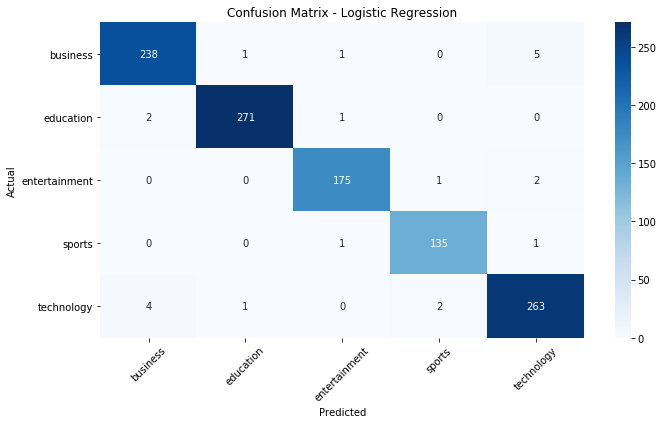

In [18]:


cm = confusion_matrix(y_val, y_pred_lr, labels=lr_model.classes_)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


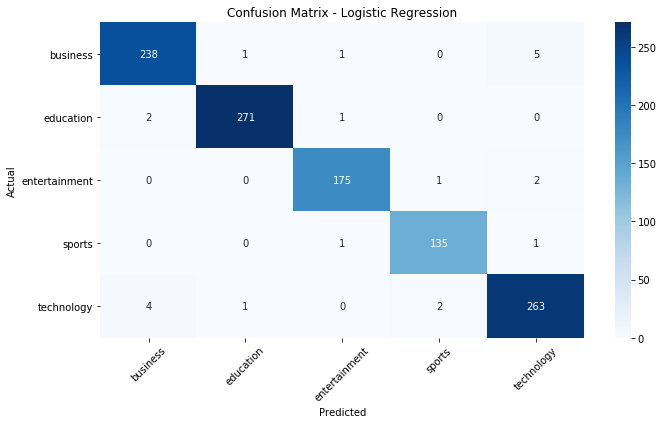

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       245
    education       0.97      0.99      0.98       274
entertainment       0.98      0.93      0.96       178
       sports       0.96      0.95      0.96       137
   technology       0.91      0.94      0.93       270

  avg / total       0.95      0.95      0.95      1104



In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Replace y_val and y_pred with your actual variables
cm = confusion_matrix(y_val, y_pred_lr, labels=sorted(set(y_val)))
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(y_val)),
            yticklabels=sorted(set(y_val)))
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Classification Report - Logistic Regression:")
print(classification_report(y_val, y_pred_rf))


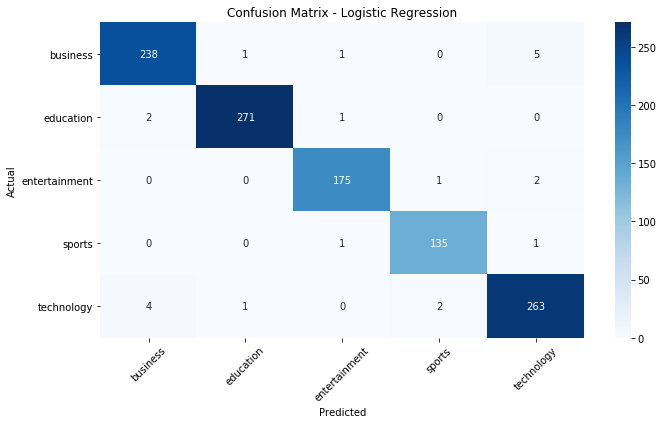

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

     business       0.98      0.97      0.97       245
    education       0.99      0.99      0.99       274
entertainment       0.98      0.98      0.98       178
       sports       0.98      0.99      0.98       137
   technology       0.97      0.97      0.97       270

  avg / total       0.98      0.98      0.98      1104



In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Replace y_val and y_pred with your actual variables
cm = confusion_matrix(y_val, y_pred_lr, labels=sorted(set(y_val)))
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(y_val)),
            yticklabels=sorted(set(y_val)))
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Classification Report - Logistic Regression:")
print(classification_report(y_val, y_pred_lr))


In [19]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

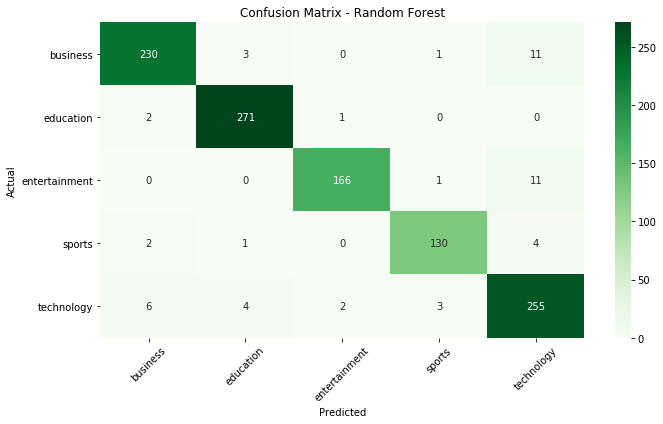

In [21]:
# Confusion Matrix for Random Forest using seaborn heatmap
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm_rf = confusion_matrix(y_val, y_pred_rf, labels=rf_model.classes_)

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(cm_rf, annot=True, fmt='d',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


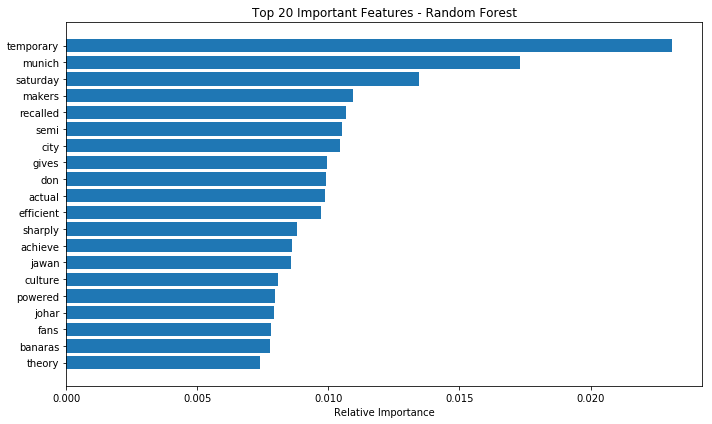

In [23]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-20:]  # Top 20 features

# Extract feature names from vocabulary
feature_names = np.array(list(vectorizer.vocabulary_.keys()))
top_features = feature_names[indices]

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), top_features)
plt.xlabel('Relative Importance')
plt.title('Top 20 Important Features - Random Forest')
plt.tight_layout()
plt.show()
